In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# Load output files to use for score
subreddit_vectors = pd.read_csv("subreddit_vectors.csv")
kmeans_results = pd.read_csv("kmeans_results.csv")

In [3]:
print("NaN count per column:")
print(subreddit_vectors.isnull().sum())

NaN count per column:
subreddit                              0
emotional_entropy_mean                 0
emotional_entropy_std                  0
emotional_entropy_median               0
emotional_entropy_min                  0
emotional_entropy_max                  0
valence_mixing_mean                    0
valence_mixing_std                     0
valence_mixing_median                  0
valence_mixing_min                     0
valence_mixing_max                     0
multi_label_count_mean                 0
multi_label_count_std                  0
multi_label_count_median               0
multi_label_count_min                  0
multi_label_count_max                  0
example_very_unclear_mean              0
example_very_unclear_std               0
example_very_unclear_median            0
example_very_unclear_min               0
example_very_unclear_max               0
unclear_fraction_mean                  0
unclear_fraction_std                   0
unclear_fraction_median            

In [4]:
subreddit_vectors.head()

,subreddit,emotional_entropy_mean,emotional_entropy_std,emotional_entropy_median,emotional_entropy_min,emotional_entropy_max,valence_mixing_mean,valence_mixing_std,valence_mixing_median,valence_mixing_min,...,unclear_fraction_std,unclear_fraction_median,unclear_fraction_min,unclear_fraction_max,annotator_disagreement_score_mean,annotator_disagreement_score_std,annotator_disagreement_score_median,annotator_disagreement_score_min,annotator_disagreement_score_max,comment_count
0,2meirl4meirl,1.158655,0.862172,1.0,0.0,3.000000,0.462674,0.531690,0.0,0.0,...,0.0,0.0,0.0,0.0,0.091706,0.063832,0.074074,0.0,0.296296,731
1,49ers,1.064176,0.868678,1.0,0.0,3.000000,0.426306,0.530975,0.0,0.0,...,0.0,0.0,0.0,0.0,0.086400,0.058167,0.074074,0.0,0.296296,640
2,4PanelCringe,1.036009,0.826075,1.0,0.0,3.000000,0.364408,0.525175,0.0,0.0,...,0.0,0.0,0.0,0.0,0.083880,0.056992,0.074074,0.0,0.296296,695
3,90DayFiance,1.110898,0.848668,1.0,0.0,2.584963,0.438451,0.521034,0.0,0.0,...,0.0,0.0,0.0,0.0,0.087626,0.058893,0.074074,0.0,0.222222,798
4,90dayfianceuncensored,1.006428,0.856285,1.0,0.0,2.807355,0.437112,0.525822,0.0,0.0,...,0.0,0.0,0.0,0.0,0.080458,0.060124,0.074074,0.0,0.259259,789


In [5]:
kmeans_results.head()

,k,inertia,cluster_labels
0,2,6137.5675,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, ..."
1,3,5228.7422,"[2, 2, 2, 0, 0, 0, 2, 0, 1, 2, 2, 0, 1, 0, 2, ..."
2,4,4820.9288,"[2, 2, 2, 1, 2, 1, 2, 1, 0, 2, 2, 1, 0, 1, 2, ..."
3,5,4347.7409,"[0, 0, 0, 2, 2, 2, 0, 2, 3, 0, 0, 2, 3, 2, 0, ..."
4,6,4000.6032,"[2, 2, 2, 3, 3, 1, 3, 1, 5, 2, 2, 1, 5, 3, 2, ..."


In [6]:
# Feature columns — everything except subreddit name and comment_count
# Ignore features the subreddit name (TypeError) and comment count (we want to group by emotional complexity)
ignore_cols = ["subreddit", "comment_count"]
feature_cols = [c for c in subreddit_vectors.columns if c not in ignore_cols]

In [7]:
print("Emotional Complexity Features")
print(subreddit_vectors[feature_cols].head())

Emotional Complexity Features
   emotional_entropy_mean  emotional_entropy_std  emotional_entropy_median  \
0                1.158655               0.862172                       1.0   
1                1.064176               0.868678                       1.0   
2                1.036009               0.826075                       1.0   
3                1.110898               0.848668                       1.0   
4                1.006428               0.856285                       1.0   

   emotional_entropy_min  emotional_entropy_max  valence_mixing_mean  \
0                    0.0               3.000000             0.462674   
1                    0.0               3.000000             0.426306   
2                    0.0               3.000000             0.364408   
3                    0.0               2.584963             0.438451   
4                    0.0               2.807355             0.437112   

   valence_mixing_std  valence_mixing_median  valence_mixing_min  \


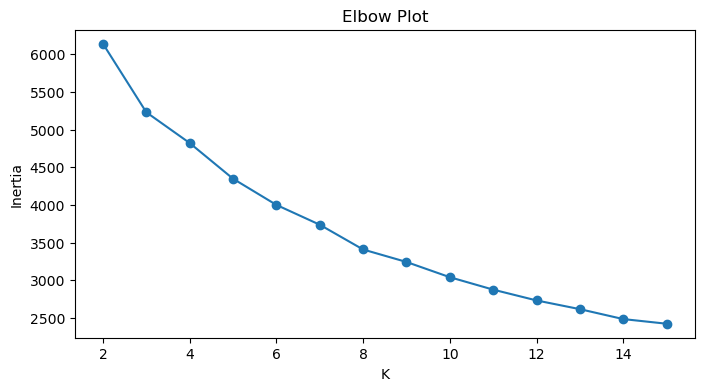

In [8]:
# Elbow plot
plt.figure(figsize=(8, 4))
plt.plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.savefig("elbow_plot.png")
plt.show()

In [9]:
X = subreddit_vectors[feature_cols].values
k_values = kmeans_results["k"].tolist()
silhouette_scores = []

# Use the kmeans results and append silhouette score
for _, row in kmeans_results.iterrows():
    labels = json.loads(row["cluster_labels"])
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

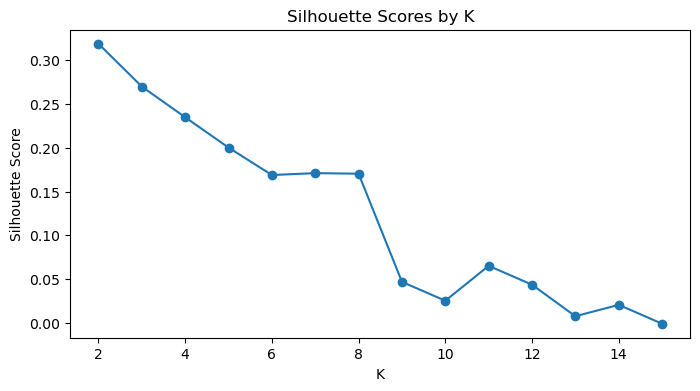

In [10]:
# Silhouette scores plot
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by K")
plt.savefig("silhouette_plot.png")
plt.show()

In [11]:
# Optimal k
optimal_k_idx = np.argmax(silhouette_scores)
optimal_k = k_values[optimal_k_idx]
print(f"Optimal K: {optimal_k}")

# Finalize cluster assignments and save
# resource: https://www.geeksforgeeks.org/python/json-loads-in-python/
optimal_labels = json.loads(kmeans_results[kmeans_results["k"] == optimal_k]["cluster_labels"].values[0])
cluster_labels_df = pd.DataFrame({
    "subreddit": subreddit_vectors["subreddit"],
    "cluster": optimal_labels
})
cluster_labels_df.to_csv("cluster_labels.csv", index=False)
print("Saved file: cluster_labels.csv")

Optimal K: 2
Saved file: cluster_labels.csv


In [12]:
print(cluster_labels_df["cluster"].unique())
print(cluster_labels_df["cluster"].value_counts())

[0 1]
cluster
0    337
1    146
Name: count, dtype: int64


In [13]:
# Manual optimal_k
optimal_k = 4
print(f"Optimal K Selected (Manually): {optimal_k}")

# Keep the rest of the code the same to save the file
optimal_labels = json.loads(kmeans_results[kmeans_results["k"] == optimal_k]["cluster_labels"].values[0])
cluster_labels_df = pd.DataFrame({
    "subreddit": subreddit_vectors["subreddit"],
    "cluster": optimal_labels
})
cluster_labels_df.to_csv("cluster_labelsk4.csv", index=False)
print("Saved file: cluster_labelsk4.csv")

Optimal K Selected (Manually): 4
Saved file: cluster_labelsk4.csv


In [14]:
print(cluster_labels_df["cluster"].unique())
print(cluster_labels_df["cluster"].value_counts())

[2 1 0 3]
cluster
1    190
2    150
0     99
3     44
Name: count, dtype: int64


In [15]:
# Manual optimal_k
optimal_k = 5
print(f"Optimal K Selected (Manually): {optimal_k}")

# Keep the rest of the code the same to save the file
optimal_labels = json.loads(kmeans_results[kmeans_results["k"] == optimal_k]["cluster_labels"].values[0])
cluster_labels_df = pd.DataFrame({
    "subreddit": subreddit_vectors["subreddit"],
    "cluster": optimal_labels
})
cluster_labels_df.to_csv("cluster_labelsk5.csv", index=False)
print("Saved file: cluster_labelsk5.csv")

Optimal K Selected (Manually): 5
Saved file: cluster_labelsk5.csv


In [16]:
print(cluster_labels_df["cluster"].unique())
print(cluster_labels_df["cluster"].value_counts())

[0 2 3 1 4]
cluster
2    196
0    141
3     82
1     63
4      1
Name: count, dtype: int64


In [17]:
print(f"Number of Subreddits: {len(subreddit_vectors)}")
print(f"Number of Cluster Labels: {len(optimal_labels)}")

if len(subreddit_vectors) != len(optimal_labels):
    print("Warning: The counts do not match")

Number of Subreddits: 483
Number of Cluster Labels: 483
